In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Data

In [2]:
df_train = pd.read_csv('data/train.csv')
df_test = pd.read_csv('data/test.csv')
df_original = pd.read_csv('data/Rainfall.csv')

### Train data

In [3]:
df_train.head()

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
0,0,1,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,60.0,17.2,1
1,1,2,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,50.0,21.9,1
2,2,3,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,70.0,18.1,1
3,3,4,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,60.0,35.6,1
4,4,5,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,40.0,24.8,0


- we remove: 'id', 'day'
- 'rainfall' is our target

In [4]:
train = df_train.copy()
train.drop(['id', 'day'], axis=1, inplace=True)
train.head()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
0,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,60.0,17.2,1
1,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,50.0,21.9,1
2,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,70.0,18.1,1
3,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,60.0,35.6,1
4,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,40.0,24.8,0


In [5]:
X_train = train.drop('rainfall', axis=1)
Y_train = train['rainfall']
target = 'rainfall'

### Test data

In [6]:
df_test.head()

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
0,2190,1,1019.5,17.5,15.8,12.7,14.9,96.0,99.0,0.0,50.0,24.3
1,2191,2,1016.5,17.5,16.5,15.8,15.1,97.0,99.0,0.0,50.0,35.3
2,2192,3,1023.9,11.2,10.4,9.4,8.9,86.0,96.0,0.0,40.0,16.9
3,2193,4,1022.9,20.6,17.3,15.2,9.5,75.0,45.0,7.1,20.0,50.6
4,2194,5,1022.2,16.1,13.8,6.4,4.3,68.0,49.0,9.2,20.0,19.4


In [7]:
test = df_test.copy()
test.drop(['id', 'day'], axis=1, inplace=True)
test.head()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
0,1019.5,17.5,15.8,12.7,14.9,96.0,99.0,0.0,50.0,24.3
1,1016.5,17.5,16.5,15.8,15.1,97.0,99.0,0.0,50.0,35.3
2,1023.9,11.2,10.4,9.4,8.9,86.0,96.0,0.0,40.0,16.9
3,1022.9,20.6,17.3,15.2,9.5,75.0,45.0,7.1,20.0,50.6
4,1022.2,16.1,13.8,6.4,4.3,68.0,49.0,9.2,20.0,19.4


### original data

In [8]:
df_original.columns= df_original.columns.str.strip()
original = df_original.copy()
original.drop(['day'], axis=1, inplace=True)
original['rainfall'] = original['rainfall'].map({'no': 0, 'yes': 1})

In [9]:
original.head()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1025.9,19.9,18.3,16.8,13.1,72,49,1,9.3,80.0,26.3
1,1022.0,21.7,18.9,17.2,15.6,81,83,1,0.6,50.0,15.3
2,1019.7,20.3,19.3,18.0,18.4,95,91,1,0.0,40.0,14.2
3,1018.9,22.3,20.6,19.1,18.8,90,88,1,1.0,50.0,16.9
4,1015.9,21.3,20.7,20.2,19.9,95,81,1,0.0,40.0,13.7


In [10]:
X_original = original.drop('rainfall', axis=1)
Y_original = original['rainfall']

# Combinations of columns

In [38]:
import itertools

In [39]:
new_columns = {}

for n in range(2, 13):
    for cols in itertools.combinations(X_train.columns, n):
        col_combination = '_'.join(cols)

        # Addition
        new_columns[f'{col_combination}_plus'] = X_train[list(cols)].sum(axis=1)

        # Subtraction
        if n == 2:
            new_columns[f'{cols[0]}_minus_{cols[1]}'] = X_train[cols[0]] - X_train[cols[1]]
            new_columns[f'{cols[1]}_minus_{cols[0]}'] = X_train[cols[1]] - X_train[cols[0]]
        else:
            for pair in itertools.combinations(cols, 2):
                new_columns[f'{pair[0]}_minus_{pair[1]}'] = X_train[pair[0]] - X_train[pair[1]]
                new_columns[f'{pair[1]}_minus_{pair[0]}'] = X_train[pair[1]] - X_train[pair[0]]

        # Multiplication
        new_columns[f'{col_combination}_times'] = X_train[list(cols)].prod(axis=1)

        # Division
        if n == 2:
            new_columns[f'{cols[0]}_div_{cols[1]}'] = X_train[cols[0]] / X_train[cols[1]]
            new_columns[f'{cols[1]}_div_{cols[0]}'] = X_train[cols[1]] / X_train[cols[0]]
        else:
            for pair in itertools.combinations(cols, 2):
                new_columns[f'{pair[0]}_div_{pair[1]}'] = X_train[pair[0]] / X_train[pair[1]]
                new_columns[f'{pair[1]}_div_{pair[0]}'] = X_train[pair[1]] / X_train[pair[0]]

df_new = pd.DataFrame(new_columns, index=X_train.index)

df_comb = pd.concat([X_train, df_new], axis=1)

df_comb.head()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,...,pressure_maxtemp_temparature_dewpoint_humidity_cloud_sunshine_winddirection_windspeed_plus,pressure_maxtemp_temparature_dewpoint_humidity_cloud_sunshine_winddirection_windspeed_times,pressure_maxtemp_mintemp_dewpoint_humidity_cloud_sunshine_winddirection_windspeed_plus,pressure_maxtemp_mintemp_dewpoint_humidity_cloud_sunshine_winddirection_windspeed_times,pressure_temparature_mintemp_dewpoint_humidity_cloud_sunshine_winddirection_windspeed_plus,pressure_temparature_mintemp_dewpoint_humidity_cloud_sunshine_winddirection_windspeed_times,maxtemp_temparature_mintemp_dewpoint_humidity_cloud_sunshine_winddirection_windspeed_plus,maxtemp_temparature_mintemp_dewpoint_humidity_cloud_sunshine_winddirection_windspeed_times,pressure_maxtemp_temparature_mintemp_dewpoint_humidity_cloud_sunshine_winddirection_windspeed_plus,pressure_maxtemp_temparature_mintemp_dewpoint_humidity_cloud_sunshine_winddirection_windspeed_times
0,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,60.0,17.2,...,1331.9,7.491536e+13,1331.2,7.236969e+13,1330.6,7.032149e+13,334.4,1.465319e+12,1351.8,1.490816e+15
1,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,50.0,21.9,...,1325.9,0.000000e+00,1324.8,0.000000e+00,1325.5,0.000000e+00,322.2,0.000000e+00,1341.7,0.000000e+00
2,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,70.0,18.1,...,1287.3,1.102724e+14,1285.8,9.999856e+13,1282.5,8.298849e+13,277.8,1.572089e+12,1301.9,1.609977e+15
3,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,60.0,35.6,...,1351.7,0.000000e+00,1350.8,0.000000e+00,1350.5,0.000000e+00,355.2,0.000000e+00,1368.6,0.000000e+00
4,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,40.0,24.8,...,1236.5,3.212659e+13,1233.3,2.653935e+13,1230.4,2.292602e+13,229.9,4.779058e+11,1251.7,4.883241e+14


In [40]:
new_columns = {}

for col1, col2 in itertools.combinations(X_train.columns, 2):
    new_columns[f'{col1}_plus_{col2}'] = X_train[col1] + X_train[col2]

    new_columns[f'{col1}_minus_{col2}'] = X_train[col1] - X_train[col2]
    new_columns[f'{col2}_minus_{col1}'] = X_train[col2] - X_train[col1]

    new_columns[f'{col1}_times_{col2}'] = X_train[col1] * X_train[col2]

    new_columns[f'{col1}_div_{col2}'] = X_train[col1] / X_train[col2]
    new_columns[f'{col2}_div_{col1}'] = X_train[col2] / X_train[col1]


df_new = pd.DataFrame(new_columns, index=X_train.index)

df_comb_pairs = pd.concat([X_train, df_new], axis=1)

df_comb_pairs.head()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,...,windspeed_minus_sunshine,sunshine_times_windspeed,sunshine_div_windspeed,windspeed_div_sunshine,winddirection_plus_windspeed,winddirection_minus_windspeed,windspeed_minus_winddirection,winddirection_times_windspeed,winddirection_div_windspeed,windspeed_div_winddirection
0,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,60.0,17.2,...,16.1,18.92,0.063953,15.636364,77.2,42.8,-42.8,1032.0,3.488372,0.286667
1,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,50.0,21.9,...,21.9,0.00,0.000000,inf,71.9,28.1,-28.1,1095.0,2.283105,0.438000
2,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,70.0,18.1,...,9.8,150.23,0.458564,2.180723,88.1,51.9,-51.9,1267.0,3.867403,0.258571
3,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,60.0,35.6,...,35.6,0.00,0.000000,inf,95.6,24.4,-24.4,2136.0,1.685393,0.593333
4,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,40.0,24.8,...,21.2,89.28,0.145161,6.888889,64.8,15.2,-15.2,992.0,1.612903,0.620000


we got some inf values, we need to replace them

In [42]:
df_comb.replace([np.inf, -np.inf], np.nan, inplace=True)
df_comb_pairs.replace([np.inf, -np.inf], np.nan, inplace=True)
df_comb.fillna(0, inplace=True)
df_comb_pairs.fillna(0, inplace=True)

## PCA

In [43]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

Explained variance ratio for each component: [0.52389643 0.19605934 0.0961157  0.06036511 0.03725926 0.02047032
 0.01172166 0.00914665]
Total variance explained by the components: 0.9550344701848785
Transformed data (first 5 rows): 
[[-22.40603867   9.62299133  -6.08569346  -2.57636655   4.69853273
    2.93469801   3.20378687  -0.29398812]
 [-30.38828156  13.39569063  -5.06949916   4.51402307   8.62061002
   10.9429642    5.1423419    1.23053565]
 [-36.3293753  -32.06673185  -7.13908601  15.14668641  -3.8352568
    0.44750568   2.71440785  10.46587042]
 [-20.84847592  24.65479806   5.57501385   8.2066062    4.27948349
   11.31911499  -1.36220627  -2.78798192]
 [-48.60645219 -39.02846633  -5.54953223  21.72709381 -10.58709846
  -20.45872799  -3.25129943  -3.80501938]]


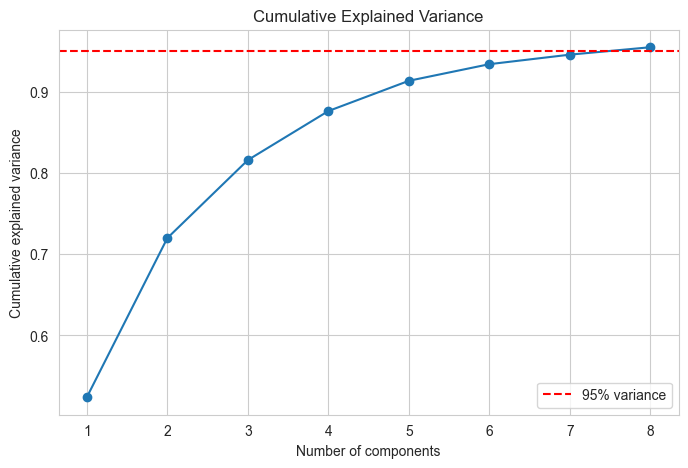

In [47]:
X = df_comb

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

print(f"Explained variance ratio for each component: {pca.explained_variance_ratio_}")
print(f"Total variance explained by the components: {sum(pca.explained_variance_ratio_)}")
print(f"Transformed data (first 5 rows): \n{X_pca[:5]}")

cum_var = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(cum_var) + 1), cum_var, marker='o')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% variance')
plt.legend()
plt.title("Cumulative Explained Variance")
plt.show()

Explained variance ratio for each component: [0.37825705 0.20570616 0.10683264 0.06682917 0.04368757 0.03128688
 0.029327   0.02408349 0.01950501 0.01824554 0.01629906 0.01159684]
Total variance explained by the components: 0.9516564115192627
Transformed data (first 5 rows): 
[[-6.82729359e+00  4.57091871e+00 -4.30663127e+00 -3.01561930e-01
   2.71298231e+00 -2.91336985e+00 -2.21677383e+00  3.10283788e+00
   2.45775040e-03 -9.11056086e-01  7.23669607e-02 -5.37526484e-03]
 [-1.37191853e+01  6.18869084e+00 -2.59017391e+00 -2.39586173e+00
   7.21035454e+00 -1.40205227e+00 -3.66660766e+00  3.19695384e+00
  -5.72311282e-01  5.96897816e-01  5.44657544e-02  1.92201663e+00]
 [-7.48423546e+00 -1.58214163e+01 -5.61455273e-01 -7.30424202e+00
   1.87335346e+00  1.12569623e+00  6.56882725e-01  9.38672619e-01
   2.87287657e+00  2.65454079e+00  2.52618434e+00 -1.57244482e+00]
 [-1.29692197e+01  8.28028097e+00  4.39635840e+00  4.59613671e-01
   6.17131991e+00  3.93873962e-01 -3.26140574e+00  8.4017227

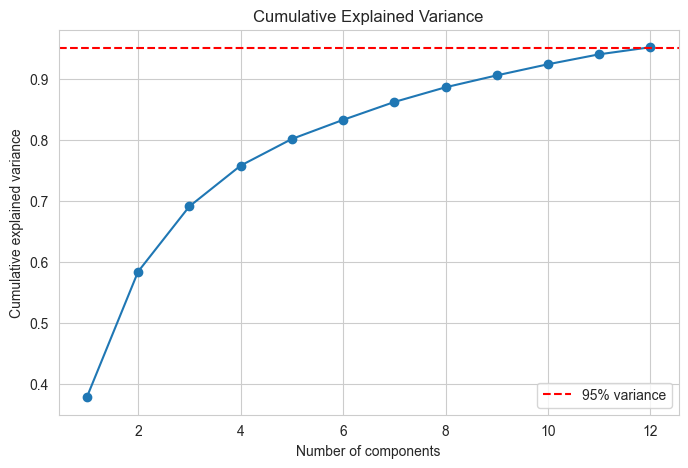

In [58]:
X = df_comb_pairs

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

print(f"Explained variance ratio for each component: {pca.explained_variance_ratio_}")
print(f"Total variance explained by the components: {sum(pca.explained_variance_ratio_)}")

print(f"Transformed data (first 5 rows): \n{X_pca[:5]}")

cum_var = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(cum_var) + 1), cum_var, marker='o')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% variance')
plt.legend()
plt.title("Cumulative Explained Variance")
plt.show()

## Checking importance of new columns

### Random Forest

In [49]:
from sklearn.ensemble import RandomForestClassifier

**Original data**

In [50]:
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, Y_train)

importances = clf.feature_importances_
features_importance_org = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)

print(features_importance_org)

cloud            0.289859
sunshine         0.187422
humidity         0.098049
dewpoint         0.066691
windspeed        0.065287
pressure         0.065258
maxtemp          0.065230
mintemp          0.061798
temparature      0.057082
winddirection    0.043324
dtype: float64


**All combinations**

In [51]:
clf = RandomForestClassifier(random_state=42)
clf.fit(df_comb, Y_train)

importances = clf.feature_importances_
features_importance_comb = pd.Series(importances, index=df_comb.columns).sort_values(ascending=False)

print(features_importance_comb)

maxtemp_humidity_cloud_plus                                                      0.022187
pressure_maxtemp_dewpoint_cloud_plus                                             0.017647
temparature_humidity_cloud_sunshine_plus                                         0.016695
dewpoint_humidity_cloud_sunshine_plus                                            0.015467
temparature_cloud_plus                                                           0.013852
                                                                                   ...   
maxtemp_temparature_mintemp_dewpoint_humidity_cloud_sunshine_times               0.000000
pressure_maxtemp_mintemp_dewpoint_humidity_cloud_winddirection_windspeed_plus    0.000000
temparature_mintemp_dewpoint_humidity_sunshine_winddirection_plus                0.000000
pressure_maxtemp_temparature_humidity_cloud_sunshine_winddirection_times         0.000000
pressure_temparature_dewpoint_humidity_sunshine_winddirection_plus               0.000000
Length: 22

In [52]:
features_importance_comb.head(20)

maxtemp_humidity_cloud_plus                                0.022187
pressure_maxtemp_dewpoint_cloud_plus                       0.017647
temparature_humidity_cloud_sunshine_plus                   0.016695
dewpoint_humidity_cloud_sunshine_plus                      0.015467
temparature_cloud_plus                                     0.013852
pressure_minus_cloud                                       0.013727
dewpoint_cloud_plus                                        0.013052
mintemp_humidity_cloud_plus                                0.012520
pressure_temparature_dewpoint_humidity_cloud_plus          0.011900
temparature_dewpoint_cloud_plus                            0.009454
temparature_dewpoint_humidity_cloud_plus                   0.009093
pressure_mintemp_dewpoint_cloud_plus                       0.008900
pressure_temparature_dewpoint_cloud_plus                   0.008790
pressure_maxtemp_mintemp_cloud_plus                        0.008697
maxtemp_cloud_sunshine_plus                     

**Pairs of columns**

In [55]:
clf = RandomForestClassifier(random_state=42)
clf.fit(df_comb_pairs, Y_train)

importances = clf.feature_importances_
features_importance_pairs = pd.Series(importances, index=df_comb_pairs.columns).sort_values(ascending=False)

print(features_importance_pairs)

dewpoint_plus_cloud                0.036983
cloud_minus_sunshine               0.033315
pressure_minus_cloud               0.031774
cloud_div_pressure                 0.029295
cloud_minus_pressure               0.027895
                                     ...   
windspeed_div_temparature          0.001065
maxtemp_minus_winddirection        0.001051
maxtemp_times_winddirection        0.001004
temparature_times_winddirection    0.001000
winddirection                      0.000569
Length: 280, dtype: float64


In [56]:
features_importance_pairs.head(20)

dewpoint_plus_cloud        0.036983
cloud_minus_sunshine       0.033315
pressure_minus_cloud       0.031774
cloud_div_pressure         0.029295
cloud_minus_pressure       0.027895
humidity_times_cloud       0.024970
maxtemp_plus_cloud         0.023760
temparature_plus_cloud     0.022212
mintemp_plus_cloud         0.019700
cloud_plus_sunshine        0.019120
mintemp_minus_cloud        0.016650
humidity_minus_sunshine    0.016177
temparature_minus_cloud    0.013493
pressure_plus_cloud        0.013042
cloud_minus_maxtemp        0.012324
humidity_plus_cloud        0.011646
sunshine_div_dewpoint      0.011216
cloud                      0.010617
maxtemp_minus_cloud        0.009548
cloud_plus_windspeed       0.009405
dtype: float64

**Conclusions**
- in both cases important are: dewpoint_cloud_plus, temperature_cloud_plus, pressure_minus_cloud, mintemp_cloud_plus, humidity_cloud_plus
- from all combinations we should consider:maxtemp_humidity_cloud_plus, pressure_maxtemp_dewpoint_cloud_plus, temparature_humidity_cloud_sunshine_plus, dewpoint_humidity_cloud_sunshine_plus   